# E5 Graph-Oriented Data — Summary

Summary of the **E5 graph-oriented dataset** and the PE / architecture sweep
(`e5_pe_sweep`) trained on it.

The models in this notebook were trained on an **incomplete snapshot** of
`data/gen/e5_graph_oriented_data/` — the version that existed before the
rollout-generation crash was fixed. Run this notebook from `notebooks/`.

## 1. Data description

In [180]:
import json, glob, os, re
from math import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = "../data/gen/e5_graph_oriented_data"
E5_DIR   = "../outputs/e5_pe_sweep"
ARCH_COLORS = {"rpearl": "#4c72b0", "gt": "#dd8452", "llm": "#55a868"}

In [181]:
# Snapshot used for training: split manifest + the dropped-sample error log.
manifest = json.load(open(f"{DATA_DIR}/split/split_manifest.json"))
errored  = {ln.split("\t")[0].split()[0]
            for ln in open(f"{DATA_DIR}/split/split_errors.log")
            if ln.startswith("sample_")}

train_ids = manifest["train_graph_ids"]
val_ids   = manifest["val_graph_ids"]
n_graphs  = len(train_ids) + len(val_ids)
n_tasks_per_graph = json.load(open(f"{DATA_DIR}/data_gen_params.json"))["n_tasks"]
n_attempt = n_graphs * n_tasks_per_graph
n_dropped = len(errored)
n_valid   = n_attempt - n_dropped

print("Train graph ids:", train_ids)
print("Val graph ids:  ", val_ids)

volume = pd.DataFrame([
    ("Graphs with generated plans",                                    n_graphs),
    (f"Plans attempted ({n_graphs} graphs x {n_tasks_per_graph} tasks)", n_attempt),
    ("Plans dropped (JSONDecodeError: Extra data - rollout-crash bug)", n_dropped),
    ("Valid conversations",                                            n_valid),
    ("  -> train conversations",       manifest["n_train_conversations"]),
    ("  -> val conversations",         manifest["n_val_conversations"]),
    ("Train graphs",                   len(train_ids)),
    ("Val graphs",                     len(val_ids)),
], columns=["item", "count"])
volume

Train graph ids: ['000', '001', '002', '003', '005', '006', '007', '008', '010', '012', '013', '014', '015', '017', '018', '020', '021', '022', '024', '027', '028', '030', '031', '032', '033', '034', '036', '037', '038', '039', '040', '041', '042', '043', '044', '046', '047', '048', '049']
Val graph ids:   ['004', '009', '011', '016', '019', '023', '025', '026', '029', '045']


,item,count
0,Graphs with generated plans,49
1,Plans attempted (49 graphs x 10 tasks),490
2,Plans dropped (JSONDecodeError: Extra data - r...,0
3,Valid conversations,490
4,-> train conversations,390
5,-> val conversations,100
6,Train graphs,39
7,Val graphs,10


### Graphs per size

Room/object scene graphs (`regions`, `objects`, `region_connections`,
`object_connections`). Size varies mainly by object count.

In [182]:
split_of = {g: "val" for g in val_ids}
rows = []
for gid in sorted(train_ids + val_ids):
    g = json.load(open(f"{DATA_DIR}/populated_graphs/data_gen_{gid}.json"))["graph"]
    rows.append(dict(
        graph=gid,
        regions=len(g["regions"]), objects=len(g["objects"]),
        nodes=len(g["regions"]) + len(g["objects"]),
        region_conns=len(g["region_connections"]),
        split=split_of.get(gid, "train"),
    ))
sizes = pd.DataFrame(rows)
print("node counts (regions + objects):", sorted(sizes["nodes"]))
sizes

node counts (regions + objects): [19, 20, 21, 22, 22, 22, 24, 24, 25, 26, 28, 28, 31, 31, 31, 33, 33, 33, 34, 34, 35, 35, 36, 37, 37, 39, 40, 41, 41, 42, 42, 42, 45, 46, 46, 46, 46, 47, 47, 48, 48, 49, 50, 51, 52, 52, 53, 55, 56]


,graph,regions,objects,nodes,region_conns,split
0,000,18,3,21,35,train
1,001,18,4,22,39,train
2,002,18,6,24,36,train
3,003,18,8,26,33,train
4,004,18,4,22,33,val
5,005,18,6,24,29,train
6,006,18,1,19,32,train
7,007,18,2,20,32,train
8,008,18,7,25,30,train
9,009,18,4,22,31,val


### Distribution of tasks per category

Task type is not stored in the task JSON; categories are assigned by the
heuristic classifier below (route regex -> Navigability; single-node regex ->
Positionality; yes/no with one-hop framing -> Reachability; else Existence).
The classifier defaults unframed yes/no tasks to Existence, so Existence is
mildly inflated at the expense of Reachability.

In [183]:
TASK_TYPES = ["Existence", "Positionality", "Reachability", "Navigability"]
TYPE_COLORS = {"Existence": "#4c72b0", "Positionality": "#dd8452",
               "Reachability": "#55a868", "Navigability": "#c44e52"}

def classify_task(task_text, answer_regex):
    # Heuristic task-type label (the type is not stored in the task JSON).
    nodes = re.findall(r"[a-z][a-z_]*_\d+", answer_regex)   # e.g. freight_corridor_1
    is_yesno = (r"\byes\b" in answer_regex) or (r"\bno\b" in answer_regex)
    if ".*" in answer_regex and len(nodes) >= 2:
        return "Navigability"                  # route: A .* B [.* C]
    if nodes and not is_yesno:
        return "Positionality"                 # single node-name lookup
    t = task_text.lower()
    existence_cues = ["is there a", "is there any", "whether there is",
                      "whether there", "includes any", "stored anywhere",
                      "any single", "exist"]
    reach_cues = ["directly from", "move directly", "in one move", "in one step",
                  "one hop", "direct link", "direct connection",
                  "directly connected to"]
    if any(k in t for k in existence_cues):
        return "Existence"
    if any(k in t for k in reach_cues):
        return "Reachability"
    return "Existence"                         # default for unframed yes/no

task_rows = []
for gid in sorted(train_ids + val_ids):
    tasks = json.load(open(f"{DATA_DIR}/populated_graphs/data_gen_{gid}.json"))["tasks"]
    for ti, task in enumerate(tasks):
        fn = f"sample_{gid}_{ti:03d}.json"
        task_rows.append(dict(
            graph=gid, task_idx=ti,
            task_type=classify_task(task["task"], task["answer"]),
            used=fn not in errored,
            task=task["task"], answer=task["answer"], init_node=task["init_node"],
        ))
tasks_df = pd.DataFrame(task_rows)

dist = pd.DataFrame({
    "generated":         tasks_df["task_type"].value_counts(),
    "used_for_training": tasks_df[tasks_df["used"]]["task_type"].value_counts(),
}).reindex(TASK_TYPES).fillna(0).astype(int)
dist["gen_share"]  = (dist["generated"]         / dist["generated"].sum()).round(3)
dist["used_share"] = (dist["used_for_training"] / dist["used_for_training"].sum()).round(3)
dist

,generated,used_for_training,gen_share,used_share
task_type,,,,
Existence,92,92,0.188,0.188
Positionality,65,65,0.133,0.133
Reachability,35,35,0.071,0.071
Navigability,298,298,0.608,0.608


### Examples per task type

One representative task per category, taken from the plans used for training.

In [184]:
for tt in TASK_TYPES:
    ex = tasks_df[(tasks_df["task_type"] == tt) & tasks_df["used"]].iloc[0]
    print(f"=== {tt}  (graph {ex.graph}, task {ex.task_idx}) ===")
    print(f"task      : {ex.task}")
    print(f"answer    : {ex.answer}")
    print(f"init_node : {ex.init_node}")
    print()

=== Existence  (graph 000, task 6) ===
task      : Is there a single area in the complex where visitors can buy refreshments and that also connects directly onto a rooftop terrace, or are those functions always in separate places?
answer    : (?i)\byes\b
init_node : storage_bunker_1

=== Positionality  (graph 000, task 3) ===
task      : In which specific area of the underground levels is the secure safe that holds the museum's most valuable artifacts located?
answer    : (?i)\bvault_1\b
init_node : terrace_2

=== Reachability  (graph 000, task 2) ===
task      : From the central glass atrium, can the robot move directly in a single step into the rooftop garden area with the planted trees, without passing through any other rooms first?
answer    : (?i)\byes\b
init_node : atrium_1

=== Navigability  (graph 000, task 0) ===
task      : Is there a route from the small upper terrace with the binocular viewing area to the underground storage bunker for large artworks that passes through the

### Held-out test set (cross-eval graphs)

The 2 val-split graphs (`data_gen_003`, `data_gen_007`) are held out of
training and serve as the cross-eval test set in Section 3. Cross-eval scores
**all 10 tasks of each test graph** (20 tasks total) directly from the
populated graph — it needs no generated plan, so the test set is not shrunk by
the rollout-crash bug the way the training split is.

In [185]:
test_graphs = sorted(val_ids)
test_tasks  = tasks_df[tasks_df["graph"].isin(test_graphs)]
train_tasks = tasks_df[tasks_df["graph"].isin(train_ids)]

print("Test graphs:", test_graphs)
print(f"Cross-eval test tasks: {len(test_tasks)} "
      f"({len(test_graphs)} graphs x {n_tasks_per_graph} tasks)")
print(f"  of which kept as val conversations during training: "
      f"{int(test_tasks['used'].sum())}")

# Test graph sizes.
sizes[sizes["graph"].isin(test_graphs)].reset_index(drop=True)

Test graphs: ['004', '009', '011', '016', '019', '023', '025', '026', '029', '045']
Cross-eval test tasks: 100 (10 graphs x 10 tasks)
  of which kept as val conversations during training: 100


,graph,regions,objects,nodes,region_conns,split
0,004,18,4,22,33,val
1,009,18,4,22,31,val
2,011,24,7,31,63,val
3,016,24,10,34,61,val
4,019,24,4,28,62,val
5,023,30,11,41,93,val
6,025,30,12,42,99,val
7,026,30,10,40,90,val
8,029,30,5,35,87,val
9,045,40,10,50,148,val


In [186]:
# Task-type composition: training graphs vs held-out test set.
comp = pd.DataFrame({
    "train_graphs": train_tasks["task_type"].value_counts(),
    "test_graphs":  test_tasks["task_type"].value_counts(),
}).reindex(TASK_TYPES).fillna(0).astype(int)
comp["train_share"] = (comp["train_graphs"] / comp["train_graphs"].sum()).round(3)
comp["test_share"]  = (comp["test_graphs"]  / comp["test_graphs"].sum()).round(3)
comp

,train_graphs,test_graphs,train_share,test_share
task_type,,,,
Existence,75,17,0.192,0.17
Positionality,50,15,0.128,0.15
Reachability,30,5,0.077,0.05
Navigability,235,63,0.603,0.63


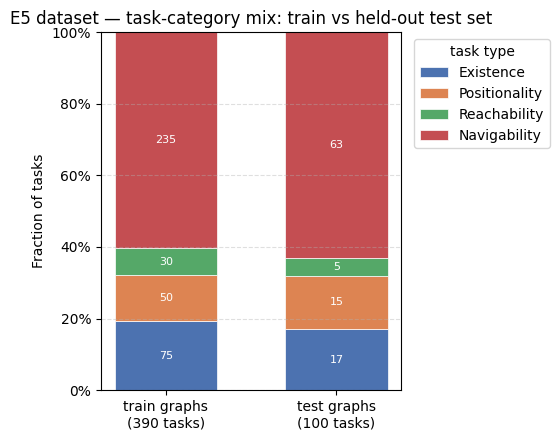

In [187]:
# Task-category mix: training graphs vs held-out test set.
groups = ["train_graphs", "test_graphs"]
labels = [f"{g.replace('_', ' ')}\n({int(comp[g].sum())} tasks)" for g in groups]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
x = np.arange(len(groups))
bottom = np.zeros(len(groups))
for tt in TASK_TYPES:
    fracs = (comp.loc[tt, groups] / comp[groups].sum()).values
    ax.bar(x, fracs, bottom=bottom, width=0.6, color=TYPE_COLORS[tt],
           label=tt, edgecolor="white", linewidth=0.5)
    for i, (frac, b) in enumerate(zip(fracs, bottom)):
        if frac > 0.04:
            ax.text(i, b + frac / 2, str(int(comp.loc[tt, groups[i]])),
                    ha="center", va="center", fontsize=8, color="white")
    bottom += fracs
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Fraction of tasks")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.0)
ax.set_title("E5 dataset — task-category mix: train vs held-out test set")
ax.legend(title="task type", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 2. Training setup — HP sweep

`scripts/e5_train_and_eval.sbatch` — a 7-task SLURM array (`--array=0-6%7`,
`dgx-b200`). All partitions train on the same e5 dataset and cross-eval on its
held-out test graphs. The **e4 baseline hparams** are
`pe_hidden=256, d_model=1024, L=5, k_pe=3` (GT adds `k_gt=2, gt_num_layers=3,
gt_heads=8`); idx 5-6 reproduce them exactly as a reference point, idx 0-4
sweep around them. `e5_llm` is a text-only baseline (graph serialized into the
prompt) trained separately on the same e5 dataset — **not** part of the array.

In [188]:
# idx 0-6 mirror the per-task arrays in scripts/e5_train_and_eval.sbatch;
# idx 7 (e5_llm) is the text-only baseline trained separately.
CONFIGS = [
    dict(idx=0, label="cfg1",         save_name="e5_cfg1_rpearl_pe4096_dm4096_L5",
         arch="rpearl", pe_hidden=4096, d_model=4096, L=5, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=1, label="cfg2",         save_name="e5_cfg2_rpearl_pe4096_dm4096_L2",
         arch="rpearl", pe_hidden=4096, d_model=4096, L=2, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=2, label="cfg3",         save_name="e5_cfg3_gt_pe4096_dm4096_L2",
         arch="gt",     pe_hidden=4096, d_model=4096, L=2, k_pe=2, k_gt=2, gt_layers=2),
    dict(idx=3, label="cfg4-rpearl",  save_name="e5_cfg4_rpearl_pe256_dm4096_L2",
         arch="rpearl", pe_hidden=256,  d_model=4096, L=2, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=4, label="cfg4-gt",      save_name="e5_cfg4_gt_pe256_dm4096_L2",
         arch="gt",     pe_hidden=256,  d_model=4096, L=2, k_pe=2, k_gt=2, gt_layers=2),
    dict(idx=5, label="e4ref-rpearl", save_name="e5_e4ref_rpearl_pe256_dm1024_L5",
         arch="rpearl", pe_hidden=256,  d_model=1024, L=5, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=6, label="e4ref-gt",     save_name="e5_e4ref_gt_pe256_dm1024_L5",
         arch="gt",     pe_hidden=256,  d_model=1024, L=5, k_pe=3, k_gt=2, gt_layers=3),
    dict(idx=7, label="llm",          save_name="e5_llm",
         arch="llm",    pe_hidden=None, d_model=None, L=None, k_pe=None, k_gt=None, gt_layers=None),
]

# Resolve each save_name to its checkpoint dir (train_v2 appends "_{wandb_id}").
for c in CONFIGS:
    matches = sorted(d for d in glob.glob(os.path.join(E5_DIR, c["save_name"] + "_*"))
                     if os.path.isdir(d))
    c["ckpt_dir"] = matches[0] if matches else None
    c["run_id"]   = os.path.basename(matches[0]).rsplit("_", 1)[-1] if matches else None
present = [c for c in CONFIGS if c["ckpt_dir"]]
print(f"Found {len(present)}/{len(CONFIGS)} runs under {E5_DIR}")

sweep = pd.DataFrame([{
    "idx": c["idx"], "config": c["label"], "arch": c["arch"],
    "pe_hidden": c["pe_hidden"], "d_model": c["d_model"], "L": c["L"],
    "k_pe": c["k_pe"], "k_gt": c["k_gt"], "gt_layers": c["gt_layers"],
    "wandb_run": c["run_id"],
} for c in CONFIGS])
sweep

Found 8/8 runs under ../outputs/e5_pe_sweep


,idx,config,arch,pe_hidden,d_model,L,k_pe,k_gt,gt_layers,wandb_run
0,0,cfg1,rpearl,4096.0,4096.0,5.0,3.0,NaN,NaN,jad3gxsg
1,1,cfg2,rpearl,4096.0,4096.0,2.0,3.0,NaN,NaN,8yikr0fk
2,2,cfg3,gt,4096.0,4096.0,2.0,2.0,2.0,2.0,mvdap4k7
3,3,cfg4-rpearl,rpearl,256.0,4096.0,2.0,3.0,NaN,NaN,rbg6w5c4
4,4,cfg4-gt,gt,256.0,4096.0,2.0,2.0,2.0,2.0,nuohivct
5,5,e4ref-rpearl,rpearl,256.0,1024.0,5.0,3.0,NaN,NaN,ko2bsa21
6,6,e4ref-gt,gt,256.0,1024.0,5.0,3.0,2.0,3.0,8haqdvt5
7,7,llm,llm,NaN,NaN,NaN,NaN,NaN,NaN,r5pbg901


## 3. Results

Cross-eval on the 2 held-out e5 test graphs, 20 rollouts per config. wandb:
entity `alelab`, project `GREP-PRISM` (`https://wandb.ai/alelab/GREP-PRISM/runs/<id>`).

In [189]:
# Per-rollout cross-eval table.
# NOTE: every cross_eval rollout carries idx=0 (a bug in
# eval_checkpoint_on_graphs.py); rollouts are emitted in task order.
cross_rows, sample_rows = [], []
for c in present:
    for f in sorted(glob.glob(os.path.join(c["ckpt_dir"], "eval_logs/cross_eval/*.json"))):
        d = json.load(open(f))
        graph = os.path.splitext(os.path.basename(f))[0]
        cross_rows.append(dict(label=c["label"], arch=c["arch"], graph=graph,
                               accuracy=d["accuracy"]))
        for s in d["samples"]:
            sample_rows.append(dict(label=c["label"], arch=c["arch"], graph=graph,
                                    correct=bool(s["correct"])))
cross_df  = pd.DataFrame(cross_rows)
sample_df = pd.DataFrame(sample_rows)
print(f"Loaded {len(present)} configs, {len(sample_df)} rollouts")

Loaded 8 configs, 160 rollouts


In [190]:
# Pooled cross-eval accuracy per config.
summary = (sample_df.groupby(["label", "arch"], sort=False)
           .agg(correct=("correct", "sum"), n=("correct", "size")).reset_index())
summary["accuracy"] = summary["correct"] / summary["n"]
summary = summary.sort_values("accuracy", ascending=False).reset_index(drop=True)

# Sweep results table: config, arch, hparams, wandb run id, accuracy.
meta = pd.DataFrame([{
    "label": c["label"],
    "hparams (pe/dm/L)": (f'{c["pe_hidden"]}/{c["d_model"]}/{c["L"]}'
                          if c["arch"] != "llm" else "text-only"),
    "wandb_run": c["run_id"],
} for c in CONFIGS])
results = summary.merge(meta, on="label", how="left")
results = results[["label", "arch", "hparams (pe/dm/L)", "wandb_run",
                   "correct", "n", "accuracy"]]
results

,label,arch,hparams (pe/dm/L),wandb_run,correct,n,accuracy
0,e4ref-gt,gt,256/1024/5,8haqdvt5,12,20,0.60
1,cfg4-gt,gt,256/4096/2,nuohivct,10,20,0.50
2,cfg2,rpearl,4096/4096/2,8yikr0fk,9,20,0.45
3,cfg4-rpearl,rpearl,256/4096/2,rbg6w5c4,9,20,0.45
4,llm,llm,text-only,r5pbg901,8,20,0.40
5,cfg1,rpearl,4096/4096/5,jad3gxsg,7,20,0.35
6,cfg3,gt,4096/4096/2,mvdap4k7,6,20,0.30
7,e4ref-rpearl,rpearl,256/1024/5,ko2bsa21,5,20,0.25


In [191]:
# Accuracy per held-out test graph.
cross_df.pivot_table(index=["label", "arch"], columns="graph",
                     values="accuracy", sort=False)

,graph,data_gen_003,data_gen_007
label,arch,,
cfg1,rpearl,0.2,0.5
cfg2,rpearl,0.4,0.5
cfg3,gt,0.2,0.4
cfg4-rpearl,rpearl,0.5,0.4
cfg4-gt,gt,0.6,0.4
e4ref-rpearl,rpearl,0.3,0.2
e4ref-gt,gt,0.5,0.7
llm,llm,0.4,0.4


### Cross-eval accuracy ± 1 SE

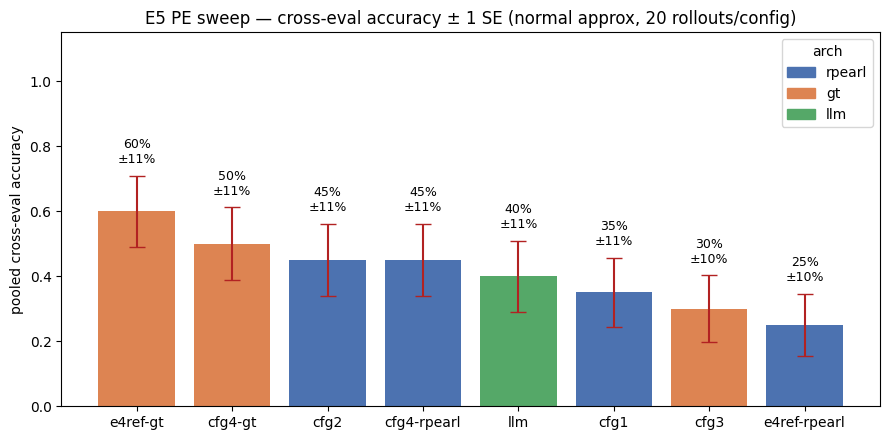

In [192]:
# Standard error of the mean accuracy for a binary outcome: sqrt(p(1-p)/n).
sem = [sqrt(p * (1 - p) / n) for p, n in zip(summary["accuracy"], summary["n"])]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [ARCH_COLORS.get(a, "#888888") for a in summary["arch"]]
ax.bar(summary["label"], summary["accuracy"], color=colors,
       yerr=sem, capsize=6, error_kw=dict(elinewidth=1.5, ecolor="#b22222"))
for i, (row, e) in enumerate(zip(summary.itertuples(), sem)):
    ax.text(i, row.accuracy + e + 0.03, f"{row.accuracy:.0%}\n±{e:.0%}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("pooled cross-eval accuracy")
ax.set_title("E5 PE sweep — cross-eval accuracy ± 1 SE "
             "(normal approx, 20 rollouts/config)")
archs_seen = [a for a in ["rpearl", "gt", "llm"] if a in summary["arch"].values]
handles = [plt.Rectangle((0, 0), 1, 1, color=ARCH_COLORS[a]) for a in archs_seen]
ax.legend(handles, archs_seen, title="arch")
plt.tight_layout()
plt.show()

## 4. Transferability (partial)

Transferability + permutation-equivariance eval for the best E5 checkpoint per
architecture, run by `scripts/e5_transferability.sbatch`:

| Condition | Checkpoint | Cross-eval acc (Section 3) |
|---|---|---|
| RPEARL   | `e5_cfg4_rpearl_pe256_dm4096_L2_rbg6w5c4` | 45% |
| GT       | `e5_cfg4_gt_pe256_dm4096_L2_nuohivct`     | 50% |
| BASELINE | `e5_llm_r5pbg901` (text-only)             | 40% |

Each checkpoint is evaluated on `eval_graph_unique_{10,30,50,100,250}` — 10
graph instances per size — under 3 node-permutation seeds (32, 42, 58). Sizes
500/1000 were dropped (the populate model truncates graphs that large).

**These results are partial** — the eval job is still running, so coverage is
uneven across cells; the loader and plots below use whatever has landed.

In [193]:
TRANSFER_DIR        = "../results/e5_transferability"
TRANSFER_DATA_DIR   = "../data/eval/e5_transferability"
TRANSFER_SEED_DIRS  = ["perm_32", "perm_42", "perm_58"]
TRANSFER_SIZES      = [10, 30, 50, 100, 250]
TRANSFER_CONDITIONS = ["BASELINE", "GT", "RPEARL"]

# checkpoint dir name -> condition label
TRANSFER_RUNS = {
    "e5_cfg4_rpearl_pe256_dm4096_L2_rbg6w5c4": "RPEARL",
    "e5_cfg4_gt_pe256_dm4096_L2_nuohivct":     "GT",
    "e5_llm_r5pbg901":                         "BASELINE",
}
CONDITION_COLORS = {"BASELINE": "#2196F3", "GT": "#4CAF50", "RPEARL": "#FF9800"}

### Transferability eval suite

`data/eval/e5_transferability/` — `eval_graph_unique_{N}_s{seed}.json`, one
scene graph + tasks per file. The suffix `N` is the unique-objects tier; node
and edge counts grow with `N`.

In [194]:
suite_rows = []
for size in TRANSFER_SIZES:
    files = sorted(glob.glob(os.path.join(
        TRANSFER_DATA_DIR, f"eval_graph_unique_{size}_s*.json")))
    if not files:
        continue
    nodes, edges, ntasks = [], [], []
    for fp in files:
        d = json.load(open(fp))
        g = d["graph"]
        nodes.append(len(g["objects"]) + len(g["regions"]))
        edges.append(len(g["object_connections"]) + len(g["region_connections"]))
        ntasks.append(len(d["tasks"]))
    suite_rows.append(dict(
        graph_size=size, n_graphs=len(files),
        mean_nodes=round(np.mean(nodes), 1),
        mean_edges=round(np.mean(edges), 1),
        tasks_per_graph=int(round(np.mean(ntasks))),
    ))
pd.DataFrame(suite_rows).set_index("graph_size")

,n_graphs,mean_nodes,mean_edges,tasks_per_graph
graph_size,,,,
10,10,10.8,12.2,10
30,10,30.2,65.4,10
50,10,49.4,146.1,10
100,10,98.8,459.3,10
250,10,247.4,2591.4,10


### Task-category distribution per graph size

Each transferability graph carries 10 tasks; categories are assigned by the
same `classify_task` heuristic used in Section 1.

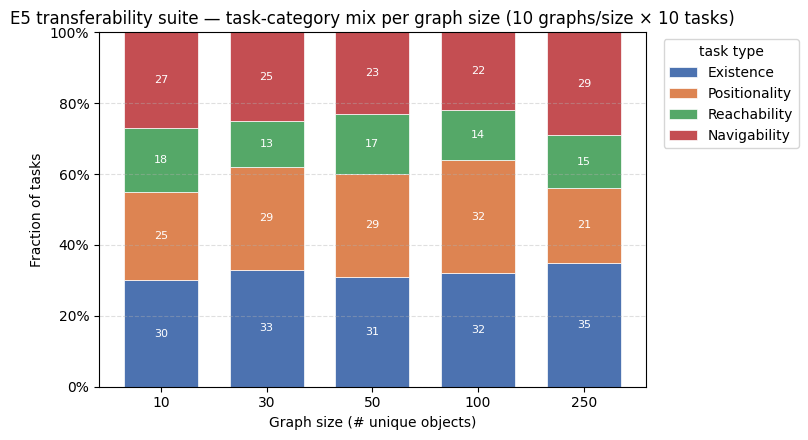

task_type,Existence,Positionality,Reachability,Navigability
graph_size,,,,
10,30,25,18,27
30,33,29,13,25
50,31,29,17,23
100,32,32,14,22
250,35,21,15,29


In [195]:
# Classify every task in the transferability eval suite.
tt_rows = []
for size in TRANSFER_SIZES:
    for fp in sorted(glob.glob(os.path.join(
            TRANSFER_DATA_DIR, f"eval_graph_unique_{size}_s*.json"))):
        for task in json.load(open(fp))["tasks"]:
            tt_rows.append(dict(
                graph_size=size,
                task_type=classify_task(task["task"], task["answer"])))
tt_df = pd.DataFrame(tt_rows)

tt_counts = (tt_df.groupby(["graph_size", "task_type"]).size()
             .unstack(fill_value=0)
             .reindex(index=TRANSFER_SIZES, columns=TASK_TYPES, fill_value=0))
tt_fracs = tt_counts.div(tt_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(TRANSFER_SIZES))
bottom = np.zeros(len(TRANSFER_SIZES))
for tt in TASK_TYPES:
    vals = tt_fracs[tt].values
    ax.bar(x, vals, bottom=bottom, width=0.7, color=TYPE_COLORS[tt],
           label=tt, edgecolor="white", linewidth=0.5)
    for i, (frac, b) in enumerate(zip(vals, bottom)):
        if frac > 0.04:
            ax.text(i, b + frac / 2, str(tt_counts[tt].values[i]),
                    ha="center", va="center", fontsize=8, color="white")
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(TRANSFER_SIZES)
ax.set_xlabel("Graph size (# unique objects)")
ax.set_ylabel("Fraction of tasks")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.0)
ax.set_title("E5 transferability suite — task-category mix per graph size "
             "(10 graphs/size × 10 tasks)")
ax.legend(title="task type", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

tt_counts

In [196]:
# Per-graph eval files (summary.json is overwritten per array task -> not used).
trial_rows, sample_rows = [], []
for seed_dir in TRANSFER_SEED_DIRS:
    perm = int(seed_dir.split("_")[1])
    for f in sorted(glob.glob(os.path.join(
            TRANSFER_DIR, seed_dir, "*eval_graph_unique_*.json"))):
        base = os.path.basename(f)
        ckpt = next((k for k in TRANSFER_RUNS if base.startswith(k)), None)
        m = re.search(r"eval_graph_unique_(\d+)_s(\d+)\.json", base)
        if ckpt is None or m is None:
            continue
        size, graph_seed = int(m.group(1)), int(m.group(2))
        cond = TRANSFER_RUNS[ckpt]
        d = json.load(open(f))
        trial_rows.append(dict(
            condition=cond, perm_seed=perm, graph_seed=graph_seed,
            graph_size=size, accuracy=d["accuracy"],
            num_correct=d["num_correct"], num_total=d["num_total"]))
        for s in d.get("samples", []):
            term = s.get("terminated_by")
            err = s.get("error") or ""
            if term == "exception":
                outcome = ("OOM" if "out of memory" in err.lower()
                           or "OutOfMemoryError" in err else "exception")
            elif s.get("correct"):
                outcome = "correct"
            else:
                outcome = term
            sample_rows.append(dict(
                condition=cond, perm_seed=perm, graph_seed=graph_seed,
                graph_size=size, outcome=outcome))

df_trans = pd.DataFrame(trial_rows)
df_fail  = pd.DataFrame(sample_rows)
print(f"Loaded {len(df_trans)} graph-instance trials, {len(df_fail)} samples")

Loaded 430 graph-instance trials, 4300 samples


In [197]:
# Coverage: trial files present per (condition, size).
# A full cell = 30 (10 graph instances x 3 perm seeds).
EXPECTED = len(TRANSFER_SEED_DIRS) * 10
cov = (df_trans.groupby(["condition", "graph_size"]).size()
       .unstack(fill_value=0)
       .reindex(index=TRANSFER_CONDITIONS, columns=TRANSFER_SIZES, fill_value=0))
print(f"Trial files present per cell (full = {EXPECTED}):")
cov

Trial files present per cell (full = 30):


graph_size,10,30,50,100,250
condition,,,,,
BASELINE,30,30,30,30,10
GT,30,30,30,30,30
RPEARL,30,30,30,30,30


### Accuracy vs graph size

Mean accuracy per condition as the graph grows, pooled over graph instances and
permutation seeds (error bars = ±1 std across those trials).

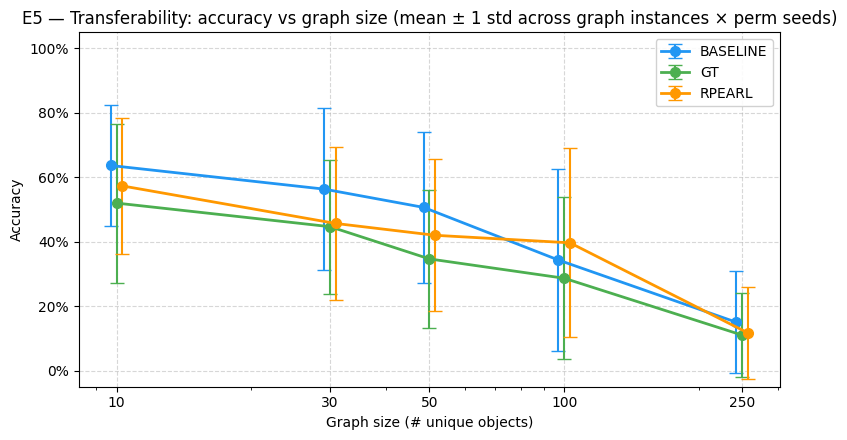

In [198]:
agg_trans = (df_trans.groupby(["condition", "graph_size"])["accuracy"]
             .agg(mean="mean", std="std", n="count").reset_index())
agg_trans["std"] = agg_trans["std"].fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
JITTER = {"BASELINE": 0.97, "GT": 1.00, "RPEARL": 1.03}
for cond in TRANSFER_CONDITIONS:
    sub = agg_trans[agg_trans["condition"] == cond].sort_values("graph_size")
    if sub.empty:
        continue
    ax.errorbar(sub["graph_size"] * JITTER[cond], sub["mean"], yerr=sub["std"],
                marker="o", color=CONDITION_COLORS[cond], label=cond,
                linewidth=2, markersize=7, elinewidth=1.5, capsize=5)
ax.set_xscale("log")
ax.set_xticks(TRANSFER_SIZES)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Graph size (# unique objects)")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E5 — Transferability: accuracy vs graph size "
             "(mean ± 1 std across graph instances × perm seeds)")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(axis="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Failure-mode breakdown

Per-sample outcomes, categorised from each sample's `terminated_by` / `correct`
/ `error` fields:

- **correct** — correct answer
- **answer** — produced an answer but it was wrong
- **bad_plan** — planner returned an invalid / unparseable plan
- **max_iterations** — agent loop hit its action-step cap
- **OOM** — exception whose error string is a CUDA out-of-memory
- **exception** — any other exception

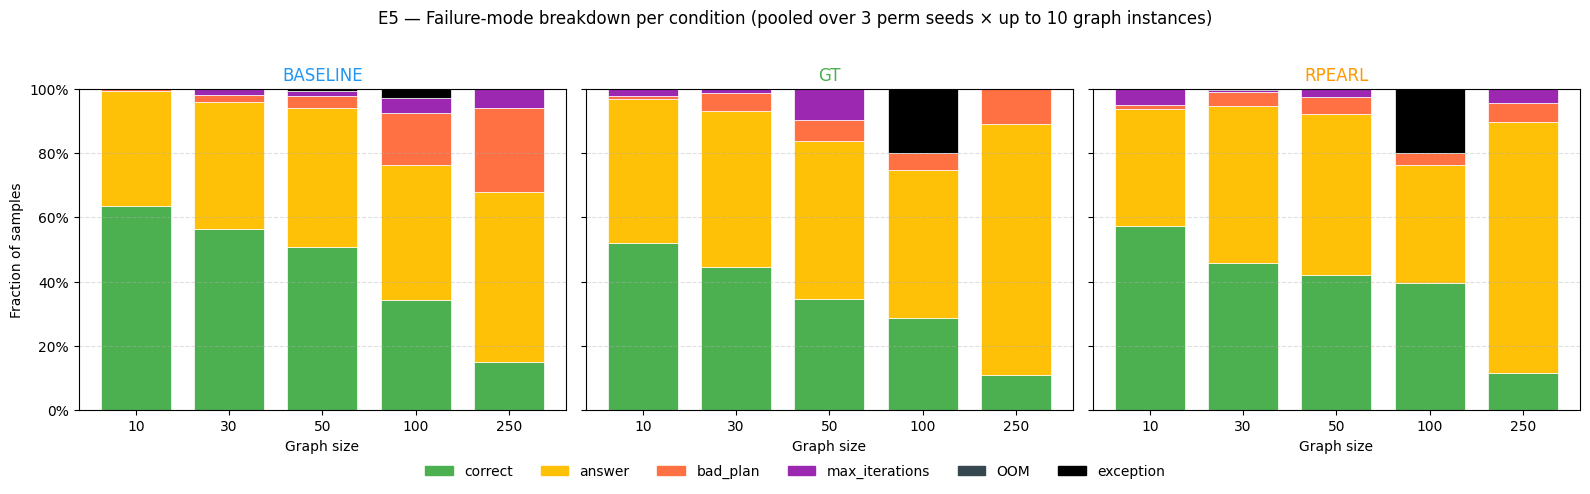

In [199]:
OUTCOME_ORDER = ["correct", "answer", "bad_plan", "max_iterations", "OOM", "exception"]
OUTCOME_COLORS = {
    "correct":        "#4CAF50",
    "answer":         "#FFC107",  # answered but wrong
    "bad_plan":       "#FF7043",
    "max_iterations": "#9C27B0",
    "OOM":            "#37474F",
    "exception":      "#000000",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, condition in zip(axes, TRANSFER_CONDITIONS):
    sub = df_fail[df_fail["condition"] == condition]
    counts = (
        sub.groupby(["graph_size", "outcome"]).size().unstack(fill_value=0)
        .reindex(index=TRANSFER_SIZES, fill_value=0)
    )
    fracs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    cols_present = [c for c in OUTCOME_ORDER if c in fracs.columns]
    fracs = fracs.reindex(columns=cols_present, fill_value=0)

    x = np.arange(len(fracs.index))
    bottom = np.zeros(len(fracs.index))
    for outcome in fracs.columns:
        ax.bar(
            x, fracs[outcome].values, bottom=bottom,
            color=OUTCOME_COLORS[outcome], label=outcome,
            edgecolor="white", linewidth=0.5, width=0.75,
        )
        bottom += fracs[outcome].values

    ax.set_xticks(x)
    ax.set_xticklabels(fracs.index)
    ax.set_xlabel("Graph size")
    ax.set_title(condition, color=CONDITION_COLORS[condition])
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Fraction of samples")

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=OUTCOME_COLORS[o]) for o in OUTCOME_ORDER
]
fig.legend(
    legend_handles, OUTCOME_ORDER,
    loc="lower center", ncol=len(OUTCOME_ORDER),
    bbox_to_anchor=(0.5, -0.05), frameon=False,
)
fig.suptitle("E5 — Failure-mode breakdown per condition "
             "(pooled over 3 perm seeds × up to 10 graph instances)", y=1.02)
plt.tight_layout()
plt.show()

### Summary table — accuracy (mean ± std) per graph size

In [200]:
def _fmt(row):
    if row["n"] > 1:
        return f"{row['mean']*100:.0f}% ± {row['std']*100:.0f}%"
    return f"{row['mean']*100:.0f}%"

tbl = agg_trans.copy()
tbl["display"] = tbl.apply(_fmt, axis=1)
(tbl.pivot(index="condition", columns="graph_size", values="display")
    .reindex(index=TRANSFER_CONDITIONS, columns=TRANSFER_SIZES))

graph_size,10,30,50,100,250
condition,,,,,
BASELINE,64% ± 19%,56% ± 25%,51% ± 23%,34% ± 28%,15% ± 16%
GT,52% ± 25%,45% ± 21%,35% ± 21%,29% ± 25%,11% ± 13%
RPEARL,57% ± 21%,46% ± 24%,42% ± 24%,40% ± 29%,12% ± 14%
